# X5 — Análisis exploratorio del store de trades: ¿qué mueve el retorno?

Este notebook lee el `store.csv` que `X5_macro_brain.py` viene acumulando
desde el backtester (`X4_backtester.py --x5`) y hace una pasada rápida de
**Ciencia de Datos** sobre él: correlaciones, regresiones y modelos no
lineales, todo orientado a una sola pregunta — *¿cuánto está afectando cada
parámetro (K, N_EXP, LAMBDA, A, B, PERDIDA_MAX) al retorno, manteniendo todo
lo demás constante?*

Esa idea de "manteniendo todo lo demás constante" tiene nombre técnico:
**ceteris paribus** (locución latina, "las demás cosas permaneciendo
iguales"). Es el concepto central de todo este notebook y lo vamos a
explicar con calma en la Sección 3, con un ejemplo numérico antes de
formalizarlo.

Este notebook es de **exploración rápida**, no un pipeline de producción:
no reemplaza al modelo LightGBM/FT-Transformer que entrena `X5_macro_brain.py`
— es una lupa para entender, con herramientas simples y transparentes
(regresión lineal, Random Forest, gráficos), qué está pasando *ahora* con
los datos que ya se recolectaron.

**Input único que se puede cambiar:**

In [1]:
valor = 'BTCUSD'  # cualquiera de: BTCUSD, ETHUSD, TSLA, GOOGL, NVDA, AMZN

## 0. Preparación

Importamos librerías estándar de análisis de datos (`pandas`, `numpy`,
`matplotlib`) y de machine learning clásico (`scikit-learn`). A propósito
NO usamos `lightgbm` ni `statsmodels` aquí: no son parte del entorno base
de este notebook y así cualquiera puede correrlo sin instalar nada extra
(todo lo que hace `statsmodels` con una regresión lineal lo replicamos a
mano en unas líneas de álgebra con `numpy`, ver Sección 5.3 — es un buen
ejercicio para entender qué hay "debajo" de una regresión, en vez de
tratarla como caja negra).

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

SCRIPTS_DIR = Path.cwd() if (Path.cwd() / 'config.py').exists() else Path(__file__).resolve().parent
sys.path.insert(0, str(SCRIPTS_DIR))
import config as cfg  # noqa: E402

pd.set_option('display.width', 140)
plt.rcParams['figure.facecolor'] = 'white'

print(f"Analizando activo: {valor}")
print(f"Carpeta de stores de X5: {cfg.CARPETA_X5}")

Analizando activo: BTCUSD
Carpeta de stores de X5: /Users/macasaez/Desktop/claude_projects_v2/Alginvesting/resources/x5


## 1. ¿Qué hay adentro de `{valor}_store.csv`?

Cada fila del store es una **foto de un instante**: los parámetros de
configuración vigentes en ese momento (K, N_EXP, LAMBDA, A, B, LOTAJES_M,
PERDIDA_MAX), el estado del mercado (features de X2 — score fundamental —
y X3 — indicadores técnicos), el estado del portafolio (cuántas órdenes
abiertas hay, exposición en USD, etc.) y, cuando corresponde, el resultado
económico de un trade.

El store mezcla **dos tipos de fila muy distintos** (columna
`tipo_registro`), y por eso el análisis los separa de entrada:

| `tipo_registro` | ¿Cuándo se escribe? | ¿Tiene retorno realizado? |
|---|---|---|
| `oc`        | Cuando una Orden Abierta se **cierra** (se convierte en Orden Cerrada) | Sí, en `retorno_pct` / `retorno_usd` |
| `periodico` | Cada `X5_FREQ_REGISTRO_PERIODICO` velas, mientras una posición sigue **abierta** | No — la posición sigue viva, solo hay ganancia *flotante* |

En el vocabulario del proyecto (ver `CLAUDE.md`): una fila `periodico` es un
snapshot de una **Orden Abierta (OA)** que todavía no llegó a **Orden
Cerrada (OC)**. Por eso las llamamos indistintamente "históricas" — son el
pulso del portafolio en el camino, no el veredicto final.

In [3]:
def cargar_store(activo: str) -> pd.DataFrame:
    """Misma lectura que usa X5_macro_brain._cargar_store en producción:
    separador ';', tolera BOM de Excel y filas corruptas por un corte a
    mitad de escritura (on_bad_lines='skip')."""
    path = cfg.CARPETA_X5 / f'{activo}_store.csv'
    if not path.exists():
        raise FileNotFoundError(
            f"No existe {path}. ¿Corriste --recolectar para {activo} al menos una vez?"
        )
    return pd.read_csv(path, sep=';', encoding='utf-8-sig', low_memory=False, on_bad_lines='skip')


store = cargar_store(valor)
print(f"Store cargado: {len(store):,} filas, {store.shape[1]} columnas.")
print()
print("Filas por tipo_registro:")
print(store['tipo_registro'].value_counts().to_string())
print()
ts_min = pd.to_datetime(store['timestamp_oc']).min()
ts_max = pd.to_datetime(store['timestamp_oc']).max()
print(f"Rango temporal cubierto: {ts_min}  →  {ts_max}  ({(ts_max - ts_min).days} días)")

Store cargado: 10,169 filas, 154 columnas.

Filas por tipo_registro:
tipo_registro
oc           5426
periodico    4743

Rango temporal cubierto: 2024-01-03 11:00:00  →  2026-08-20 10:00:00  (959 días)


In [4]:
df_oc = store[store['tipo_registro'] == 'oc'].copy()
df_periodico = store[store['tipo_registro'] == 'periodico'].copy()

# El nombre de la columna de retorno cambió durante el desarrollo del
# proyecto (retorno_usd reemplazó a retorno_pct); el store real puede tener
# cualquiera de las dos según cuándo se generó cada fila.
TARGET_OC = 'retorno_usd' if 'retorno_usd' in df_oc.columns and df_oc['retorno_usd'].notna().any() else 'retorno_pct'

n_oc_total = len(df_oc)
n_oc_validas = df_oc[TARGET_OC].notna().sum()
print(f"Filas 'oc' (posiciones cerradas): {n_oc_total:,}")
print(f"  → de esas, {n_oc_validas:,} ({n_oc_validas / max(n_oc_total, 1):.1%}) tienen '{TARGET_OC}' registrado y sirven para el análisis A.")
if n_oc_validas < n_oc_total:
    faltan = n_oc_total - n_oc_validas
    print(f"  → las {faltan:,} restantes probablemente vienen de una versión anterior del pipeline, antes de que este campo existiera. No es un error de este notebook, es historia real del store.")
print()
print(f"Filas 'periodico' (posiciones abiertas, snapshot intermedio): {len(df_periodico):,}")
print("  → estas nunca tienen retorno realizado (por diseño); analizamos otras variables dependientes: ganancia flotante, retorno promedio de lo abierto, exposición, etc.")

df_oc_ok = df_oc[df_oc[TARGET_OC].notna()].copy()

Filas 'oc' (posiciones cerradas): 5,426
  → de esas, 1,105 (20.4%) tienen 'retorno_pct' registrado y sirven para el análisis A.
  → las 4,321 restantes probablemente vienen de una versión anterior del pipeline, antes de que este campo existiera. No es un error de este notebook, es historia real del store.

Filas 'periodico' (posiciones abiertas, snapshot intermedio): 4,743
  → estas nunca tienen retorno realizado (por diseño); analizamos otras variables dependientes: ganancia flotante, retorno promedio de lo abierto, exposición, etc.


## 2. Los "sospechosos": qué columnas vamos a mirar

Agrupamos las columnas del store por su rol. Esto no es cosmético: la
separación entre **parámetros** (lo que X5 controla) y **contexto de
mercado** (lo que X5 solo observa) es exactamente la que necesitamos para
interpretar cualquier coeficiente más adelante — un coeficiente sobre un
parámetro es una palanca que se puede accionar; un coeficiente sobre RSI
es apenas una observación sobre el mundo.

- **PARAMS** — los 6 números que X5 explora/optimiza en cada tramo del
  backtest (`K`, `N_EXP`, `LAMBDA` alimentan a X0 para recalcular soportes;
  `A`, `B` controlan el trailing stop; `PERDIDA_MAX` es el corte de
  pérdida). Quedó afuera `LOTAJES_M`: está fijo en 1 en toda la recolección
  (X5 siempre opera a lotaje mínimo desde que se congeló ese rango en
  `config_x5.py`), así que tiene varianza cero y no aporta nada a una
  regresión — de hecho, la rompería (no se puede estandarizar una columna
  constante, terminaríamos dividiendo por cero).
- **X2** — score fundamental del activo en ese instante, resumido en
  `x2_score` (rango `[0,1]`). El store también guarda sus piezas
  (`x2_score_cross`, `x2_score_tendencia`, `x2_comp_hash`, etc.), pero acá
  solo usamos el agregado final — más abajo se explica por qué mezclar el
  agregado con sus propias partes en una regresión rompe la cuenta.
- **X3** — indicadores técnicos (medias móviles, RSI, MACD, Bandas de
  Bollinger, volatilidad, drawdown, pendiente de tendencia, distancia a
  soportes). De este grupo excluimos a propósito las columnas en **nivel
  de precio absoluto** (`sma_20/50/200`, `ema_12/26`, `macd*`, `atr_14`):
  no son estacionarias — si BTC pasó de ~US$40.000 a ~US$100.000+ durante
  la ventana del store, cualquier columna en dólares va a "correlacionar"
  con el tiempo, y con eso con casi cualquier otra cosa que también
  tienda a crecer, sin que exista una relación causal real (correlación
  espuria por tendencia común). Nos quedamos con las versiones ya
  normalizadas por el propio `X3_technical_features.py`
  (`sma_dist_*`, `atr_pct`, `bb_width`, `roc_*`, etc.), que miden
  *distancia relativa* o *porcentaje*, no nivel.
- **PORTFOLIO** — el estado de las posiciones abiertas del activo en ese
  instante (cuántas OA, cuántas OE, exposición en USD, retorno promedio de
  lo abierto). Son las "otras variables dependientes" que pide el
  análisis de la Sección 6 para las filas `periodico`.

In [5]:
PARAMS_COLS = ['K', 'N_EXP', 'LAMBDA', 'A', 'B', 'PERDIDA_MAX']

# OJO con X2: 'x2_score' es una combinación lineal EXACTA de 'x2_score_cross'
# y 'x2_score_tendencia' (ver X2_fundamentals.py: score = (1-w)*cross + w*tend),
# y 'x2_score_cross' es a su vez una combinación lineal exacta de los
# 'x2_comp_*' (score = Σ peso_k * componente_k). Meter el agregado Y sus
# partes en la misma regresión es colinealidad perfecta en estado puro: al
# probar esto en la Sección 5.2 con las 17 columnas de X2 completas, los
# coeficientes explotaban a valores como -100 o +130 (sin ningún sentido
# como "desvíos estándar de efecto") aunque las predicciones del modelo
# siguieran siendo razonables — síntoma clásico de columnas redundantes.
# Nos quedamos solo con el agregado final, que es la lectura más limpia y
# económicamente interpretable ("qué tan bien parado está el activo, en una
# sola cifra [0,1]").
X2_COLS = ['x2_score']

RAW_PRICE_LEVEL = {
    'x3_sma_20', 'x3_sma_50', 'x3_sma_200', 'x3_ema_12', 'x3_ema_26',
    'x3_macd', 'x3_macd_signal', 'x3_macd_hist', 'x3_atr_14',
}
X3_COLS = [
    c for c in store.columns
    if c.startswith('x3_') and not c.endswith('_oa') and c not in RAW_PRICE_LEVEL
]

PORTFOLIO_COLS = [
    'n_ordenes_abiertas', 'n_ordenes_espera', 'exposicion_usd',
    'mean_retorno_pct_abierto', 'std_retorno_pct_abierto',
    'retorno_promedio_ultimas_5_oc', 'pnl_flotante_activo',
]
PORTFOLIO_COLS = [c for c in PORTFOLIO_COLS if c in store.columns]

CONTEXTO_COLS = X2_COLS + X3_COLS  # mercado: lo que X5 observa, no controla

print(f"PARAMS      ({len(PARAMS_COLS)}): {PARAMS_COLS}")
print(f"X2          ({len(X2_COLS)}): {X2_COLS}")
print(f"X3          ({len(X3_COLS)}): {X3_COLS}")
print(f"PORTFOLIO   ({len(PORTFOLIO_COLS)}): {PORTFOLIO_COLS}")

PARAMS      (6): ['K', 'N_EXP', 'LAMBDA', 'A', 'B', 'PERDIDA_MAX']
X2          (1): ['x2_score']
X3          (20): ['x3_sma_dist_20', 'x3_sma_dist_50', 'x3_sma_dist_200', 'x3_ema_dist_12', 'x3_ema_dist_26', 'x3_rsi_14', 'x3_atr_pct', 'x3_bb_width', 'x3_bb_pos', 'x3_roc_10', 'x3_roc_20', 'x3_vol_24h', 'x3_vol_7d', 'x3_drawdown_20', 'x3_drawdown_50', 'x3_trend_slope_20', 'x3_trend_slope_50', 'x3_dist_nearest_support', 'x3_dist_floor_support', 'x3_density_2pct']
PORTFOLIO   (7): ['n_ordenes_abiertas', 'n_ordenes_espera', 'exposicion_usd', 'mean_retorno_pct_abierto', 'std_retorno_pct_abierto', 'retorno_promedio_ultimas_5_oc', 'pnl_flotante_activo']


## 3. El concepto central: ceteris paribus, con números primero

Imaginemos un ejemplo simplificado con solo 4 trades de nuestro propio
store (números inventados para ilustrar, no son los reales):

| trade | LAMBDA | N_EXP | retorno |
|---|---|---|---|
| 1 | alto | alto | +$80 |
| 2 | alto | alto | +$75 |
| 3 | bajo | bajo | +$10 |
| 4 | bajo | bajo | +$5  |

Si solo miráramos la correlación cruda, LAMBDA alto está asociado a mejor
retorno... pero también lo está N_EXP alto, porque en estos 4 trades
**siempre se movieron juntos**. Con esta muestra es matemáticamente
imposible saber si el retorno sube por LAMBDA, por N_EXP, o por ambos —
los dos efectos están **confundidos** (en inglés, *confounded*).

La pregunta ceteris paribus es distinta: *"si comparo dos trades con el
MISMO N_EXP (y el mismo score de X2, el mismo RSI, la misma hora del día,
...) y que solo difieran en LAMBDA, ¿cambia el retorno?"*. Eso exige
**controlar estadísticamente** por las demás variables — no basta con
mirar una a la vez.

Este notebook ataca esa pregunta con dos herramientas complementarias:

1. **Regresión lineal múltiple estandarizada** (Sección 5.3): un método
   clásico. El coeficiente de cada variable ya viene "neto" del efecto de
   las demás, porque todas entran juntas a la misma ecuación.
2. **Partial Dependence (dependencia parcial)** de un Random Forest
   (Sección 5.4): el equivalente *no lineal* del punto anterior. Para
   aislar el efecto de, digamos, K: tomamos TODAS las filas reales del
   store, a cada una le cambiamos artificialmente el valor de K (dejando
   el resto de sus columnas EXACTAMENTE como estaban) y le pedimos al
   modelo que prediga el retorno. Promediamos esas predicciones. Repetimos
   para varios valores de K y armamos una curva: *"si moviera solo K, sin
   tocar nada más de cada trade real, así cambiaría el retorno esperado."*
   Esa frase — sin tocar nada más — es, literalmente, la traducción
   operacional de ceteris paribus para un modelo que no asume linealidad.

Una nota importante de diseño que hace que este análisis tenga sentido: en
`config_x5.py`, `X5_EXPLORATION_RATE = {X5_EXPLORATION_RATE:.0%}` de los
tramos del backtest usan parámetros **aleatorios**, no elegidos por el
modelo. Esto no es casualidad — es lo que en experimentación se llama
aleatorización, y es lo que evita que las correlaciones que vemos acá sean
pura consecuencia de que "el modelo eligió subir LAMBDA justo cuando el
mercado ya venía bien". Sin esa fracción de exploración aleatoria, CUALQUIER
análisis de este tipo (incluido el que hace el propio X5 al entrenarse)
estaría sesgado por la propia política de selección de parámetros.

In [6]:
print(f"X5_EXPLORATION_RATE configurado: {cfg.X5_EXPLORATION_RATE:.0%} de los tramos usan params aleatorios.")
print("(No hay una columna en el store que marque explícitamente qué filas fueron exploración vs explotación;")
print(" se deja como advertencia para leer los resultados con ese contexto, no como filtro aplicado.)")

X5_EXPLORATION_RATE configurado: 30% de los tramos usan params aleatorios.
(No hay una columna en el store que marque explícitamente qué filas fueron exploración vs explotación;
 se deja como advertencia para leer los resultados con ese contexto, no como filtro aplicado.)


## 4. Herramientas reutilizables

Definimos 3 funciones una sola vez y las usamos para ambos tipos de
registro (`oc` y `periodico`) y para varios targets — así el mismo
criterio se aplica de forma idéntica en todo el notebook.

In [7]:
def correlacion_cruda(df: pd.DataFrame, feature_cols: list, target_col: str, titulo: str) -> pd.Series:
    """Correlación de Pearson simple (una variable a la vez, SIN controlar
    por las demás). Es el punto de partida — y el ejemplo perfecto de lo que
    el análisis ceteris paribus de la Sección 5.3/5.4 va a corregir."""
    cols = [c for c in feature_cols if c in df.columns]
    sub = df[cols + [target_col]].dropna()
    if len(sub) < 5:
        print(f"  (!) Muy pocas filas ({len(sub)}) para correlación. Se omite '{titulo}'.")
        return pd.Series(dtype=float)
    corr = sub.corr(numeric_only=True)[target_col].drop(target_col)
    corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

    fig, ax = plt.subplots(figsize=(7.5, max(2.2, 0.32 * len(corr))))
    colores = ['#2a9d8f' if v >= 0 else '#e76f51' for v in corr.values]
    ax.barh(corr.index[::-1], corr.values[::-1], color=colores[::-1])
    ax.axvline(0, color='#333333', linewidth=0.8)
    ax.set_xlabel(f"Correlación de Pearson (cruda) con {target_col}")
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()
    return corr


def regresion_ceteris_paribus(df: pd.DataFrame, feature_cols: list, target_col: str,
                               min_filas: int = 30) -> pd.DataFrame | None:
    """Regresión lineal múltiple con todas las variables estandarizadas
    (z-score, media 0 y desvío 1). El coeficiente de cada variable es el
    cambio esperado en el target (en desvíos estándar) cuando esa variable
    sube 1 desvío estándar, MANTENIENDO FIJAS todas las demás — la
    definición operacional de "efecto ceteris paribus" en un modelo lineal.

    Calculado a mano con álgebra lineal (mínimos cuadrados + errores
    estándar clásicos de OLS) para no depender de statsmodels."""
    cols = [c for c in feature_cols if c in df.columns]
    sub = df[cols + [target_col]].dropna()
    n = len(sub)
    if n < min_filas:
        print(f"  (!) Solo {n} filas sin NaN (mínimo sugerido {min_filas}). Se omite la regresión.")
        return None

    X = sub[cols].to_numpy(dtype=float)
    y = sub[target_col].to_numpy(dtype=float)

    sd_x = X.std(axis=0, ddof=0)
    cols_validas = sd_x > 1e-12
    if not cols_validas.all():
        descartadas = [c for c, ok in zip(cols, cols_validas) if not ok]
        print(f"  (!) Columnas sin varianza (constantes) descartadas de la regresión: {descartadas}")
    cols = [c for c, ok in zip(cols, cols_validas) if ok]
    X = X[:, cols_validas]

    mu_x, sd_x = X.mean(axis=0), X.std(axis=0, ddof=0)
    Xz = (X - mu_x) / sd_x
    sd_y = y.std(ddof=0)
    sd_y = sd_y if sd_y > 1e-12 else 1.0
    yz = (y - y.mean()) / sd_y

    X_dis = np.column_stack([np.ones(n), Xz])
    beta, *_ = np.linalg.lstsq(X_dis, yz, rcond=None)
    y_hat = X_dis @ beta
    resid = yz - y_hat

    p = X_dis.shape[1]
    dof = n - p
    if dof <= 0:
        print("  (!) No quedan grados de libertad. Se omite la regresión.")
        return None
    sigma2 = (resid @ resid) / dof
    XtX_inv = np.linalg.pinv(X_dis.T @ X_dis)
    se = np.sqrt(np.clip(np.diag(sigma2 * XtX_inv), 0, None))
    t_val = np.divide(beta, se, out=np.zeros_like(beta), where=se > 0)
    p_val = 2 * scipy_stats.t.sf(np.abs(t_val), df=dof)

    ss_tot = ((yz - yz.mean()) ** 2).sum()
    r2 = 1 - (resid @ resid) / ss_tot if ss_tot > 1e-12 else np.nan

    tabla = pd.DataFrame({
        'feature': ['(intercepto)'] + cols,
        'coef_estandarizado': beta,
        'error_estandar': se,
        't': t_val,
        'p_valor': p_val,
    })
    tabla = tabla[tabla['feature'] != '(intercepto)'].reset_index(drop=True)
    tabla['significativo_5pct'] = tabla['p_valor'] < 0.05
    tabla = tabla.reindex(tabla['coef_estandarizado'].abs().sort_values(ascending=False).index).reset_index(drop=True)
    tabla.attrs['r2'] = r2
    tabla.attrs['n'] = n
    tabla.attrs['dof'] = dof
    return tabla


def graficar_regresion(tabla: pd.DataFrame, titulo: str) -> None:
    if tabla is None:
        return
    fig, ax = plt.subplots(figsize=(7.5, max(2.2, 0.4 * len(tabla))))
    orden = tabla.iloc[::-1]
    colores = ['#2a9d8f' if v >= 0 else '#e76f51' for v in orden['coef_estandarizado']]
    ax.barh(orden['feature'], orden['coef_estandarizado'],
            xerr=1.96 * orden['error_estandar'], color=colores, capsize=3)
    ax.axvline(0, color='#333333', linewidth=0.8)
    ax.set_xlabel('Coeficiente estandarizado (± IC 95%) — efecto ceteris paribus')
    ax.set_title(f"{titulo}\nR²={tabla.attrs.get('r2', float('nan')):.3f}  n={tabla.attrs.get('n', '?')}")
    plt.tight_layout()
    plt.show()


def modelo_no_lineal_y_pdp(df: pd.DataFrame, feature_cols: list, target_col: str,
                            features_pdp: list, titulo: str,
                            min_filas: int = 80) -> tuple | None:
    """Entrena un Random Forest (no asume relaciones lineales ni aditivas)
    y grafica Partial Dependence para 'features_pdp': el efecto ceteris
    paribus no lineal descrito en la Sección 3. Además calcula importancia
    por permutación, una forma robusta y model-agnostic de rankear qué
    variable mueve más la predicción (se mide cuánto empeora el modelo si
    se le "revuelve" al azar una sola columna, rompiendo su relación real
    con el target sin tocar las demás)."""
    cols = [c for c in feature_cols if c in df.columns]
    sub = df[cols + [target_col]].dropna()
    n = len(sub)
    if n < min_filas:
        print(f"  (!) Solo {n} filas sin NaN (mínimo sugerido {min_filas}). Se omite el modelo no lineal.")
        return None

    X, y = sub[cols], sub[target_col]
    modelo = RandomForestRegressor(
        n_estimators=400, max_depth=5, min_samples_leaf=max(5, n // 100),
        random_state=42, n_jobs=-1,
    )
    modelo.fit(X, y)
    r2_in_sample = modelo.score(X, y)
    print(f"  Random Forest entrenado con n={n} filas, {len(cols)} variables. "
          f"R² in-sample={r2_in_sample:.3f} (referencial: sin holdout, no mide generalización).")

    features_pdp = [f for f in features_pdp if f in cols]
    n_cols_grid = min(3, len(features_pdp))
    display = PartialDependenceDisplay.from_estimator(
        modelo, X, features=features_pdp, kind='average', n_cols=n_cols_grid,
    )
    fig = display.figure_
    n_filas_grid = -(-len(features_pdp) // n_cols_grid)
    fig.set_size_inches(4.2 * n_cols_grid, 3.0 * n_filas_grid)
    fig.suptitle(f"Partial Dependence — {titulo}", y=1.02)
    plt.tight_layout()
    plt.show()

    perm = permutation_importance(modelo, X, y, n_repeats=15, random_state=42, n_jobs=-1)
    importancia = pd.Series(perm.importances_mean, index=cols).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(7.5, max(2.2, 0.32 * len(importancia))))
    top = importancia.head(15).iloc[::-1]
    ax.barh(top.index, top.values, color='#264653')
    ax.set_xlabel('Importancia por permutación (caída de R² al revolver esa columna)')
    ax.set_title(f"Ranking de importancia — {titulo}")
    plt.tight_layout()
    plt.show()

    return modelo, importancia

## 5. Análisis A — Registros `oc`: qué explica el retorno ya realizado

Esta es la pregunta con más peso económico directo: de los parámetros que
X5 puede mover, ¿cuáles empujan el retorno de un trade ya cerrado, y en
qué dirección?

In [8]:
print(f"Filas 'oc' utilizables (con '{TARGET_OC}' no nulo): {len(df_oc_ok):,}")
if len(df_oc_ok) > 0:
    print(df_oc_ok[TARGET_OC].describe().to_string())
    n_ganadores = (df_oc_ok[TARGET_OC] > 0).sum()
    print(f"\nTrades con retorno positivo: {n_ganadores:,} / {len(df_oc_ok):,} ({n_ganadores/len(df_oc_ok):.1%})")

Filas 'oc' utilizables (con 'retorno_pct' no nulo): 1,105
count    1105.000000
mean        0.000005
std         0.000026
min        -0.000246
25%         0.000004
50%         0.000007
75%         0.000010
max         0.000053

Trades con retorno positivo: 1,083 / 1,105 (98.0%)


### 5.1 — Distribución del retorno

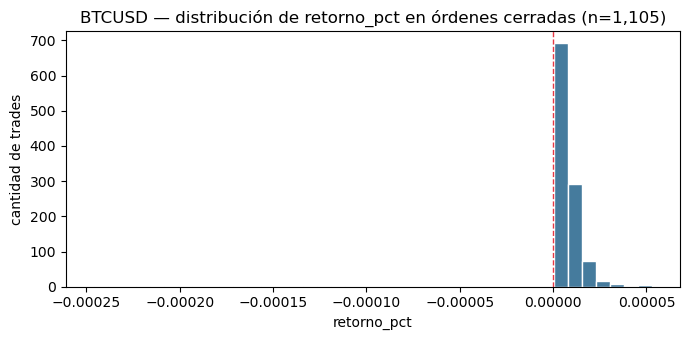

In [9]:
if len(df_oc_ok) > 0:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(df_oc_ok[TARGET_OC], bins=40, color='#457b9d', edgecolor='white')
    ax.axvline(0, color='#e63946', linestyle='--', linewidth=1)
    ax.set_xlabel(TARGET_OC)
    ax.set_ylabel('cantidad de trades')
    ax.set_title(f"{valor} — distribución de {TARGET_OC} en órdenes cerradas (n={len(df_oc_ok):,})")
    plt.tight_layout()
    plt.show()

### 5.2 — Correlación cruda (el punto de partida, todavía sin controlar nada)

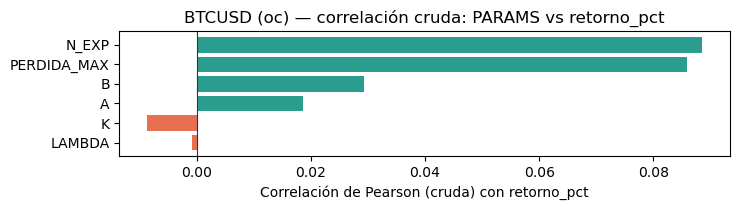

In [10]:
corr_oc_params = correlacion_cruda(df_oc_ok, PARAMS_COLS, TARGET_OC,
                                    f"{valor} (oc) — correlación cruda: PARAMS vs {TARGET_OC}")

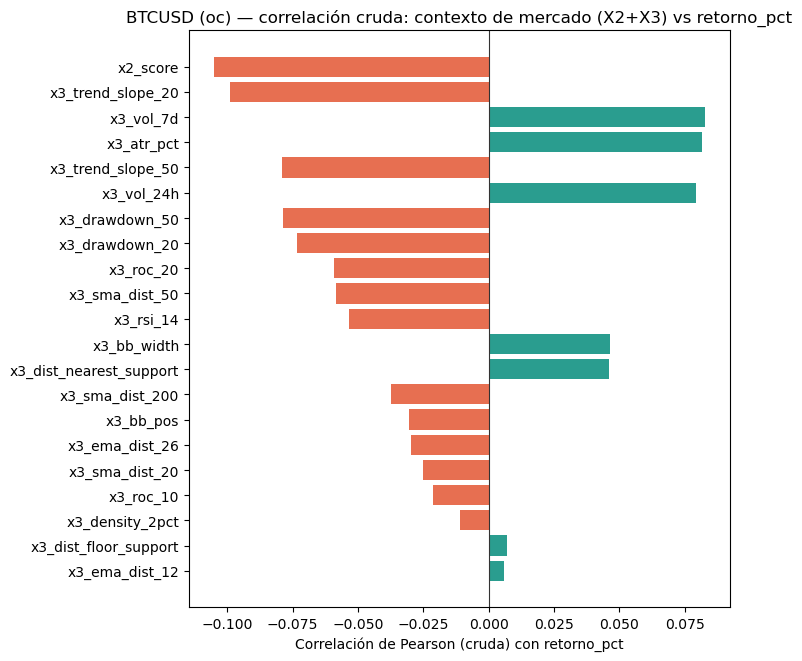

In [11]:
corr_oc_contexto = correlacion_cruda(df_oc_ok, CONTEXTO_COLS, TARGET_OC,
                                      f"{valor} (oc) — correlación cruda: contexto de mercado (X2+X3) vs {TARGET_OC}")

Antes de confiar en esos números: ¿qué tan correlacionados están los
PARAMS *entre sí*? Si dos parámetros se mueven casi siempre juntos (porque
el explorador los sortea con rangos correlacionados, o porque el modelo
aprendió a subirlos en conjunto), sus correlaciones crudas con el retorno
pueden estar "compartiendo" el mismo efecto sin que lo notemos.

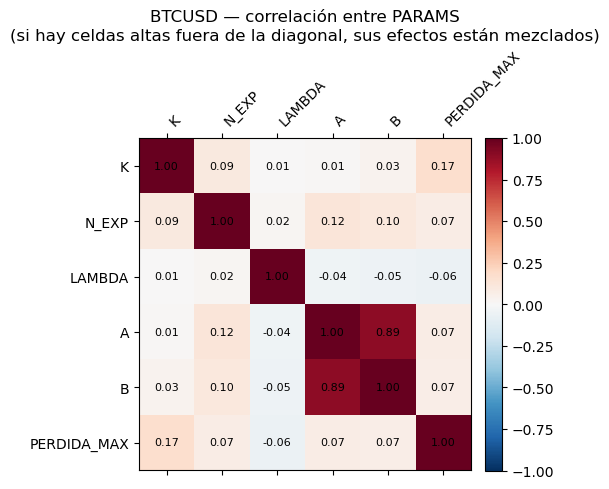

In [12]:
if len(df_oc_ok) >= 5:
    corr_matrix = df_oc_ok[PARAMS_COLS].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(5.5, 5))
    im = ax.matshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(PARAMS_COLS)))
    ax.set_xticklabels(PARAMS_COLS, rotation=45, ha='left')
    ax.set_yticks(range(len(PARAMS_COLS)))
    ax.set_yticklabels(PARAMS_COLS)
    for i in range(len(PARAMS_COLS)):
        for j in range(len(PARAMS_COLS)):
            ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
    fig.colorbar(im, fraction=0.046, pad=0.04)
    ax.set_title(f"{valor} — correlación entre PARAMS\n(si hay celdas altas fuera de la diagonal, sus efectos están mezclados)")
    plt.tight_layout()
    plt.show()

### 5.3 — Regresión ceteris paribus: separando los efectos

Ahora sí: metemos TODOS los parámetros juntos a una misma regresión.
Cada coeficiente queda "limpio" del efecto de los demás — es la respuesta
formal a la pregunta de la Sección 3.

    feature  coef_estandarizado  error_estandar         t  p_valor  significativo_5pct
      N_EXP            0.085672        0.030343  2.823425 0.004837                True
PERDIDA_MAX            0.085318        0.030535  2.794148 0.005294                True
          B            0.068134        0.066292  1.027784 0.304278               False
          A           -0.058276        0.066441 -0.877101 0.380623               False
          K           -0.032456        0.030508 -1.063851 0.287630               False
     LAMBDA            0.003732        0.030042  0.124213 0.901169               False


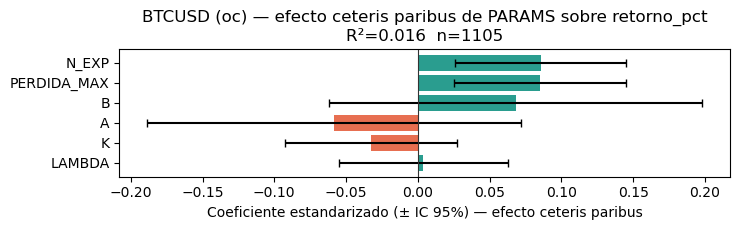

In [13]:
tabla_reg_oc_params = regresion_ceteris_paribus(df_oc_ok, PARAMS_COLS, TARGET_OC)
if tabla_reg_oc_params is not None:
    print(tabla_reg_oc_params.to_string(index=False))
    graficar_regresion(tabla_reg_oc_params, f"{valor} (oc) — efecto ceteris paribus de PARAMS sobre {TARGET_OC}")

También corremos la misma regresión agregando el contexto de mercado
(X2 + X3) junto a los parámetros — así el coeficiente de cada parámetro
queda controlado no solo por los otros parámetros, sino también por si el
RSI estaba alto, si el score fundamental era bueno, etc. Es un control
ceteris paribus más estricto (y más realista, porque X5 sí observa ese
contexto al decidir).

                feature  coef_estandarizado  error_estandar         t  p_valor  significativo_5pct
         x3_sma_dist_50           -0.864799        1.242324 -0.696114 0.486510               False
         x3_ema_dist_26            0.669346        1.926810  0.347385 0.728371               False
         x3_sma_dist_20            0.361796        1.296383  0.279081 0.780237               False
      x3_trend_slope_50            0.269765        0.289618  0.931451 0.351832               False
      x3_trend_slope_20           -0.158456        0.427039 -0.371057 0.710669               False
               x2_score           -0.135323        0.034861 -3.881813 0.000110                True
         x3_drawdown_50           -0.126533        0.100629 -1.257420 0.208878               False
            PERDIDA_MAX            0.125584        0.034707  3.618366 0.000310                True
              x3_vol_7d            0.123664        0.055153  2.242176 0.025156                True
         x

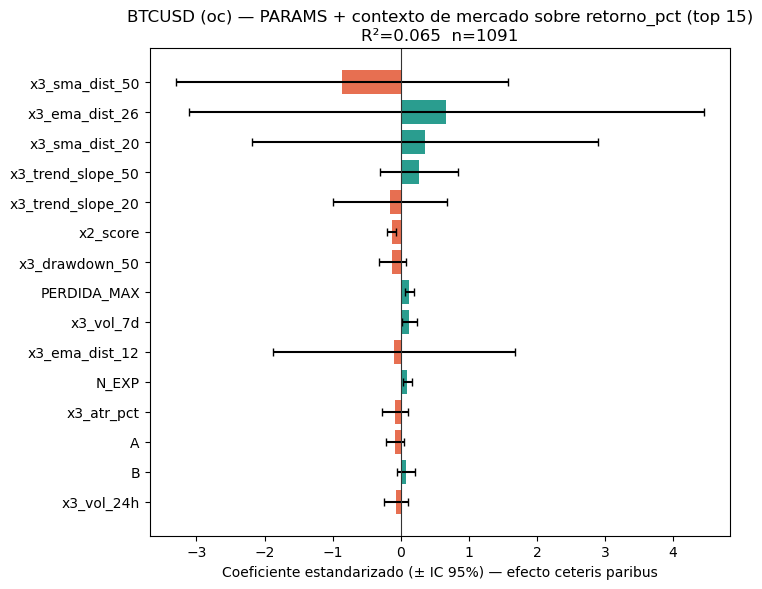

In [14]:
tabla_reg_oc_completa = regresion_ceteris_paribus(df_oc_ok, PARAMS_COLS + CONTEXTO_COLS, TARGET_OC)
if tabla_reg_oc_completa is not None:
    print(tabla_reg_oc_completa.to_string(index=False))
    graficar_regresion(tabla_reg_oc_completa.head(15),
                        f"{valor} (oc) — PARAMS + contexto de mercado sobre {TARGET_OC} (top 15)")

### 5.4 — Partial Dependence: el mismo control, pero sin asumir linealidad

La regresión de arriba asume que el efecto de cada variable es una línea
recta. Un Random Forest no asume eso — puede capturar, por ejemplo, que
LAMBDA ayude hasta cierto punto y después deje de importar, o que dé
vuelta de signo. Repetimos el análisis con esa lente.

  Random Forest entrenado con n=1091 filas, 27 variables. R² in-sample=0.341 (referencial: sin holdout, no mide generalización).


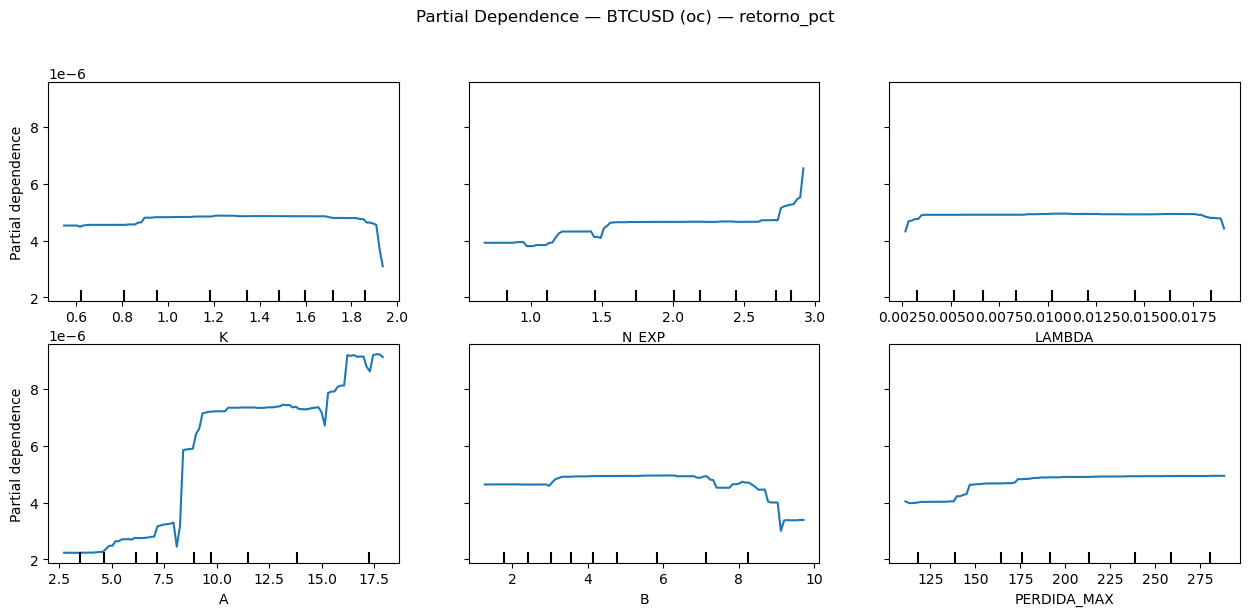

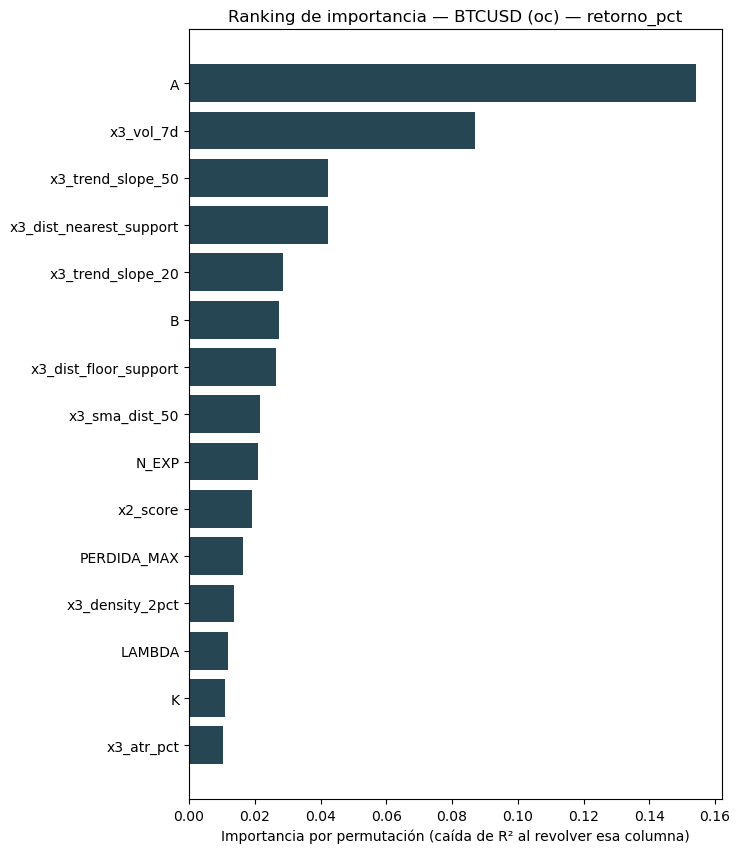

In [15]:
resultado_pdp_oc = modelo_no_lineal_y_pdp(
    df_oc_ok, PARAMS_COLS + CONTEXTO_COLS, TARGET_OC,
    features_pdp=PARAMS_COLS,
    titulo=f"{valor} (oc) — {TARGET_OC}",
)

### 5.5 — La historia hasta acá (Análisis A)

In [16]:
print(f"── Resumen narrado: {valor}, registros 'oc' ──\n")
if tabla_reg_oc_params is not None and len(tabla_reg_oc_params) > 0:
    top = tabla_reg_oc_params.iloc[0]
    signo = 'sube' if top['coef_estandarizado'] > 0 else 'baja'
    sig = 'de forma estadísticamente significativa (p<0.05)' if top['significativo_5pct'] else 'aunque SIN significancia estadística clara (p≥0.05) — podría ser ruido'
    print(f"De los {len(PARAMS_COLS)} parámetros, el que más mueve {TARGET_OC} ceteris paribus es "
          f"'{top['feature']}': cuando sube 1 desvío estándar (manteniendo el resto de los parámetros "
          f"fijos), el retorno {signo} en {abs(top['coef_estandarizado']):.3f} desvíos estándar, {sig}.")
    r2 = tabla_reg_oc_params.attrs.get('r2', float('nan'))
    print(f"El R² de esa regresión es {r2:.3f} — es decir, los parámetros por sí solos explican "
          f"~{r2:.0%} de la variación del retorno entre trades. El resto es contexto de mercado, azar, "
          f"o no linealidades que un modelo lineal no puede ver (de ahí la Sección 5.4).")
else:
    print("No hubo suficientes filas 'oc' con retorno válido para una regresión confiable todavía.")
    print(f"Con {len(df_oc_ok)} filas disponibles, conviene esperar a acumular más trades cerrados "
          f"({cfg.X5_MIN_TRADES_TRAIN} es el mínimo que el propio X5 exige antes de entrenar su modelo real).")

── Resumen narrado: BTCUSD, registros 'oc' ──

De los 6 parámetros, el que más mueve retorno_pct ceteris paribus es 'N_EXP': cuando sube 1 desvío estándar (manteniendo el resto de los parámetros fijos), el retorno sube en 0.086 desvíos estándar, de forma estadísticamente significativa (p<0.05).
El R² de esa regresión es 0.016 — es decir, los parámetros por sí solos explican ~2% de la variación del retorno entre trades. El resto es contexto de mercado, azar, o no linealidades que un modelo lineal no puede ver (de ahí la Sección 5.4).


## 6. Análisis B — Registros `periodico`: el pulso del portafolio mientras la posición sigue abierta

Acá no hay retorno realizado — la posición sigue viva. Las "otras
variables dependientes" que sí tenemos son el estado del portafolio en
ese instante: cuánta ganancia flotante hay, cuál es el retorno promedio de
lo que está abierto, cuánta exposición en USD, etc.

La pregunta cambia levemente: ya no es *"¿qué determina el resultado
final?"* sino *"¿qué determina que, en un momento cualquiera mientras la
posición sigue viva, las cosas vayan bien o mal?"*. Es información más
fresca (no hay que esperar al cierre) pero también más ruidosa (todavía
puede cambiar).

In [17]:
print(f"Filas 'periodico' disponibles: {len(df_periodico):,}")
if len(df_periodico) > 0:
    print(df_periodico[PORTFOLIO_COLS].describe().to_string())

Filas 'periodico' disponibles: 4,743
       n_ordenes_abiertas  n_ordenes_espera  exposicion_usd  mean_retorno_pct_abierto  std_retorno_pct_abierto  retorno_promedio_ultimas_5_oc  pnl_flotante_activo
count         4743.000000       4743.000000     4743.000000               4743.000000              4743.000000                    4743.000000          4743.000000
mean            13.586338         83.292009    10318.401739                 -0.035798                 0.023118                       0.000006          -542.947893
std             10.468087         42.512386     7473.784668                  0.031792                 0.015794                       0.000015           733.187701
min              1.000000         10.000000      442.283100                 -0.157916                 0.000000                      -0.000170         -5277.127500
25%              5.000000         51.000000     4500.871800                 -0.051463                 0.011073                       0.000005       

### 6.1 — Target principal: `mean_retorno_pct_abierto`

Es el análogo, para posiciones todavía abiertas, del retorno realizado de
la Sección 5: el retorno porcentual promedio de las OA activas del activo
en ese instante.

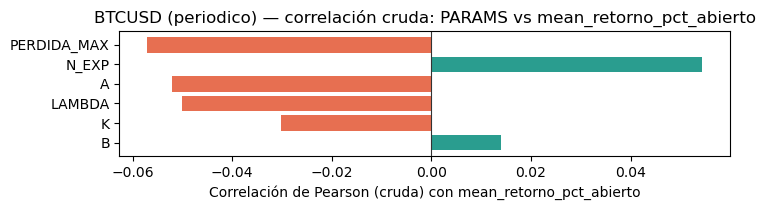

In [18]:
TARGET_PERIODICO_1 = 'mean_retorno_pct_abierto'

corr_per_params = correlacion_cruda(df_periodico, PARAMS_COLS, TARGET_PERIODICO_1,
                                     f"{valor} (periodico) — correlación cruda: PARAMS vs {TARGET_PERIODICO_1}")

              feature  coef_estandarizado  error_estandar          t       p_valor  significativo_5pct
       x3_ema_dist_26           -1.647555        0.502135  -3.281098  1.041609e-03                True
       x3_sma_dist_50            1.149630        0.364114   3.157332  1.602314e-03                True
       x3_ema_dist_12            0.686958        0.236389   2.906055  3.677325e-03                True
      x3_sma_dist_200            0.546477        0.023390  23.363641 2.739028e-114                True
    x3_trend_slope_50           -0.381978        0.109977  -3.473245  5.188592e-04                True
            x3_vol_7d           -0.182092        0.017788 -10.236584  2.448824e-24                True
x3_dist_floor_support           -0.149882        0.013204 -11.351542  1.763447e-29                True
       x3_drawdown_50            0.130067        0.034400   3.780991  1.581502e-04                True
                    B            0.120429        0.023501   5.124513  3.1

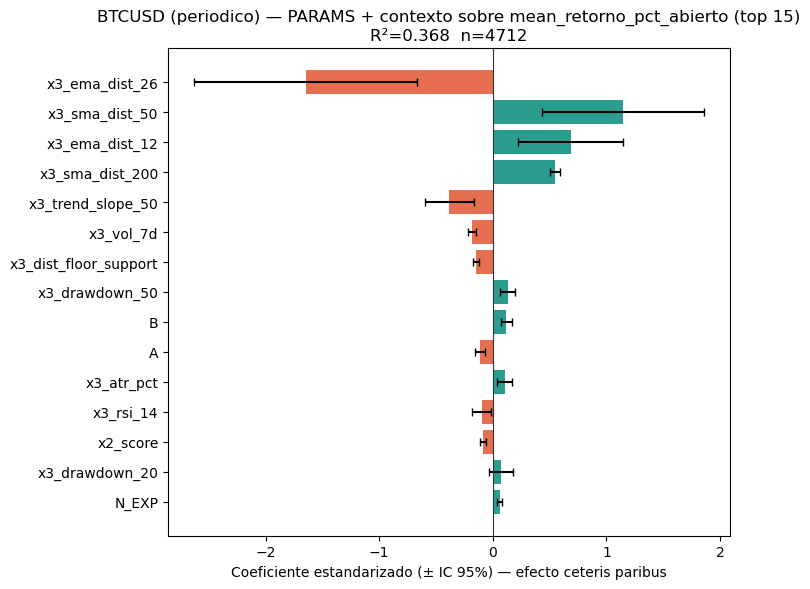

In [19]:
tabla_reg_per = regresion_ceteris_paribus(df_periodico, PARAMS_COLS + CONTEXTO_COLS, TARGET_PERIODICO_1)
if tabla_reg_per is not None:
    print(tabla_reg_per.head(15).to_string(index=False))
    graficar_regresion(tabla_reg_per.head(15),
                        f"{valor} (periodico) — PARAMS + contexto sobre {TARGET_PERIODICO_1} (top 15)")

  Random Forest entrenado con n=4712 filas, 27 variables. R² in-sample=0.598 (referencial: sin holdout, no mide generalización).


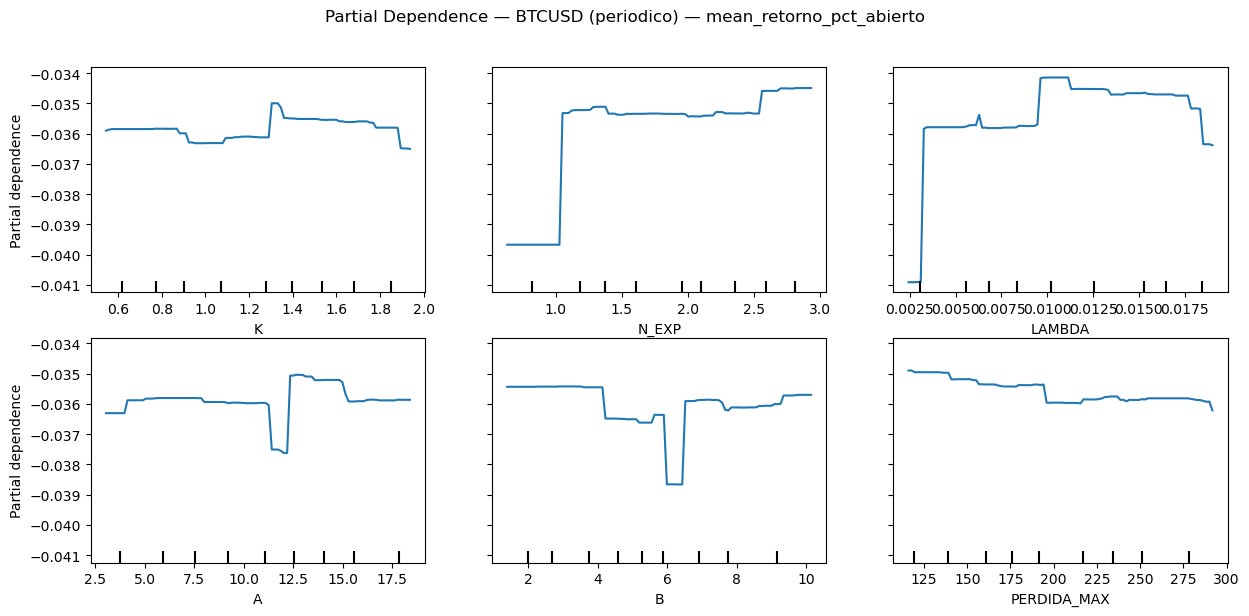

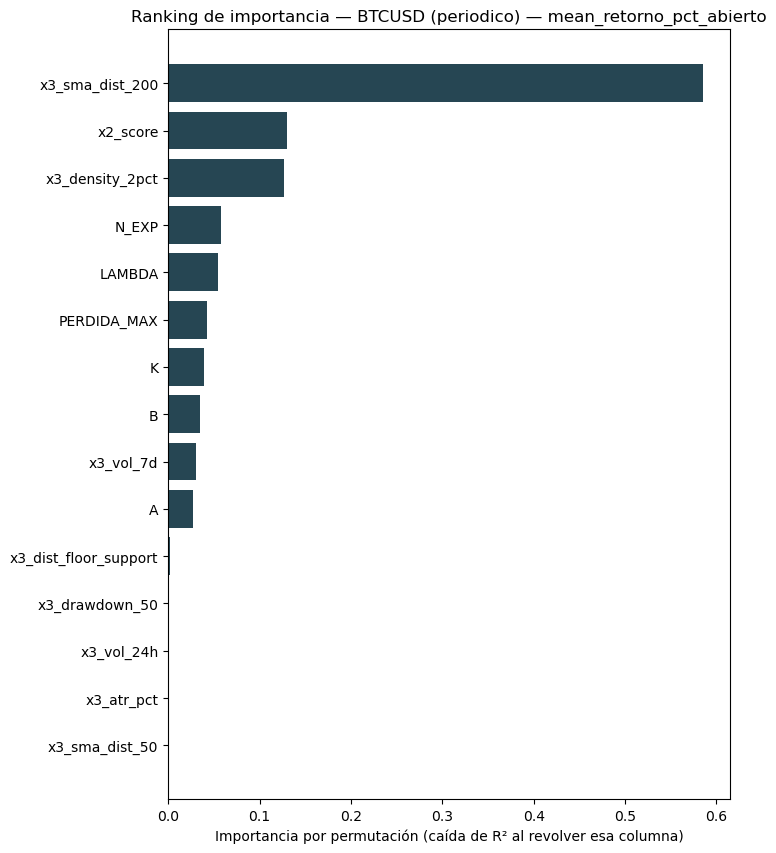

In [20]:
resultado_pdp_per = modelo_no_lineal_y_pdp(
    df_periodico, PARAMS_COLS + CONTEXTO_COLS, TARGET_PERIODICO_1,
    features_pdp=PARAMS_COLS,
    titulo=f"{valor} (periodico) — {TARGET_PERIODICO_1}",
)

### 6.2 — Segundo target: `pnl_flotante_activo`

Ganancia flotante del activo completo (suma de todas sus OA), en USD. A
diferencia del anterior, esta métrica escala con cuántas posiciones hay
abiertas a la vez — no es puramente "calidad" de las posiciones, también
es "cantidad". La leemos como complemento, no como sustituto de 6.1.

                feature  coef_estandarizado  error_estandar         t      p_valor  significativo_5pct
         x3_ema_dist_26           -1.204147        0.539685 -2.231206 2.571465e-02                True
         x3_sma_dist_50            0.875517        0.391343  2.237213 2.531931e-02                True
        x3_sma_dist_200            0.444321        0.025139 17.674472 9.987429e-68                True
         x3_ema_dist_12            0.419286        0.254065  1.650305 9.894762e-02               False
      x3_trend_slope_50           -0.334623        0.118201 -2.830961 4.660627e-03                True
         x3_drawdown_50            0.196569        0.036973  5.316601 1.106385e-07                True
              x3_rsi_14           -0.128653        0.046111 -2.790062 5.291102e-03                True
              x3_vol_7d           -0.120783        0.019119 -6.317572 2.903602e-10                True
            PERDIDA_MAX           -0.103225        0.012895 -8.005039 1.4

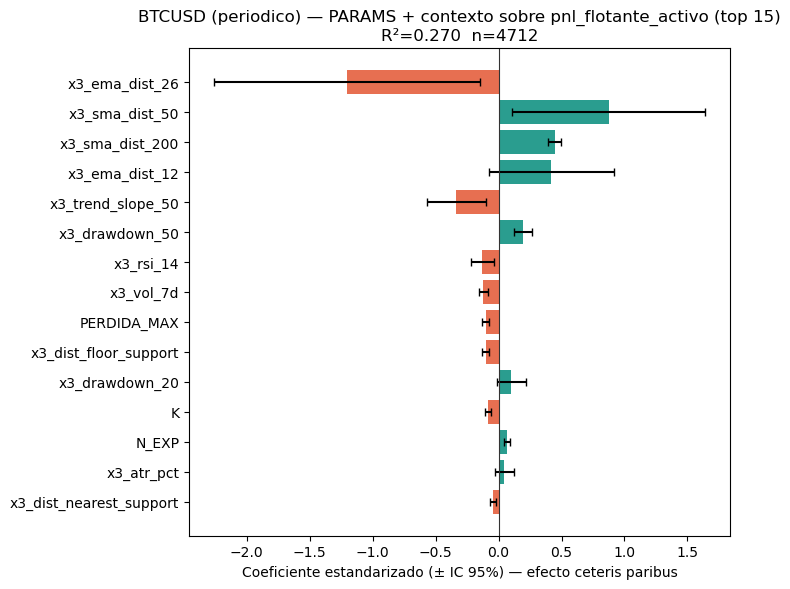

In [21]:
TARGET_PERIODICO_2 = 'pnl_flotante_activo'

tabla_reg_per2 = regresion_ceteris_paribus(df_periodico, PARAMS_COLS + CONTEXTO_COLS, TARGET_PERIODICO_2)
if tabla_reg_per2 is not None:
    print(tabla_reg_per2.head(15).to_string(index=False))
    graficar_regresion(tabla_reg_per2.head(15),
                        f"{valor} (periodico) — PARAMS + contexto sobre {TARGET_PERIODICO_2} (top 15)")

### 6.3 — La historia hasta acá (Análisis B)

In [22]:
print(f"── Resumen narrado: {valor}, registros 'periodico' ──\n")
if tabla_reg_per is not None and len(tabla_reg_per) > 0:
    top = tabla_reg_per.iloc[0]
    signo = 'sube' if top['coef_estandarizado'] > 0 else 'baja'
    print(f"Mirando TODO junto (parámetros + contexto de mercado), lo que más mueve "
          f"'{TARGET_PERIODICO_1}' ceteris paribus es '{top['feature']}' ({signo} "
          f"{abs(top['coef_estandarizado']):.3f} desvíos estándar por cada desvío estándar de esa "
          f"variable, R²={tabla_reg_per.attrs.get('r2', float('nan')):.3f}).")

    solo_params = tabla_reg_per[tabla_reg_per['feature'].isin(PARAMS_COLS)]
    if len(solo_params) > 0:
        top_param = solo_params.iloc[0]
        signo_p = 'sube' if top_param['coef_estandarizado'] > 0 else 'baja'
        sig_p = 'significativo (p<0.05)' if top_param['significativo_5pct'] else 'no significativo (p≥0.05)'
        print(f"Pero de los parámetros que X5 SÍ puede accionar (no el contexto de mercado, que solo se "
              f"observa), el de mayor efecto es '{top_param['feature']}': {signo_p} "
              f"{abs(top_param['coef_estandarizado']):.3f} desvíos estándar, efecto {sig_p}.")
else:
    print("No hubo suficientes filas 'periodico' para una regresión confiable todavía.")

── Resumen narrado: BTCUSD, registros 'periodico' ──

Mirando TODO junto (parámetros + contexto de mercado), lo que más mueve 'mean_retorno_pct_abierto' ceteris paribus es 'x3_ema_dist_26' (baja 1.648 desvíos estándar por cada desvío estándar de esa variable, R²=0.368).
Pero de los parámetros que X5 SÍ puede accionar (no el contexto de mercado, que solo se observa), el de mayor efecto es 'B': sube 0.120 desvíos estándar, efecto significativo (p<0.05).


## 7. Conclusiones y límites de este análisis

**Qué sí podemos decir:** con los datos recolectados hasta ahora para
`{valor}`, este notebook aisló, con dos métodos distintos (regresión lineal
y Partial Dependence de un Random Forest), el efecto de cada parámetro de
X5 sobre el retorno realizado y sobre el estado intermedio del portafolio,
controlando por el resto de los parámetros y por el contexto de mercado.

**Qué hay que tener presente antes de actuar sobre esto:**

1. **Correlacional, no causal en sentido estricto.** Controlar por
   variables observadas reduce el confounding, pero no lo elimina si hay
   variables relevantes que no están en el store (ej. régimen de mercado no
   capturado por X2/X3).
2. **La aleatorización parcial (`X5_EXPLORATION_RATE`) ayuda, pero no está
   aislada en este análisis.** Filtrar solo filas de exploración daría una
   lectura más limpia, pero el store no guarda ese flag hoy — quedaría
   como una mejora futura (agregar una columna `es_exploracion` en
   `_append_x5_store`).
3. **Tamaño de muestra.** Los resultados de la Sección 5 (registros `oc`)
   dependen de cuántos trades cerrados con retorno válido existan — con
   pocas decenas, cualquier coeficiente es apenas indicativo. Las funciones
   de este notebook avisan explícitamente cuando la muestra es chica en
   vez de reportar un número poco confiable en silencio.
4. **R² in-sample del Random Forest no mide generalización** — no hay
   conjunto de validación separado. Es intencional: el objetivo acá es
   describir la relación en los datos que ya existen (ceteris paribus como
   herramienta de diagnóstico), no predecir datos futuros — para eso está
   el pipeline de entrenamiento real de `X5_macro_brain.py`.
5. **No es un reemplazo del modelo de X5.** Es una lupa manual y
   transparente; el modelo real (LightGBM o FT-Transformer, según cuántos
   trades haya) ya hace algo más sofisticado (ponderación temporal,
   optimización de la recomendación vía Optuna/gradient ascent) — este
   notebook sirve para *entender* esas decisiones, no para reemplazarlas.

In [23]:
print("Fin del análisis. Cambiá la variable 'valor' en la Sección 0 y volvé a correr todo el notebook")
print("para repetir esta misma historia con otro activo (ETHUSD, TSLA, GOOGL, NVDA, AMZN).")

Fin del análisis. Cambiá la variable 'valor' en la Sección 0 y volvé a correr todo el notebook
para repetir esta misma historia con otro activo (ETHUSD, TSLA, GOOGL, NVDA, AMZN).
